Dataset shape: (20, 12)
Random Forest Accuracy : 25.0%
Decision Tree Accuracy : 25.0%
RF Cross-Val Accuracy  : 30.0%
               precision    recall  f1-score   support

Finger Millet       1.00      1.00      1.00         1
    Groundnut       0.00      0.00      0.00         1
    Horsegram       0.00      0.00      0.00         1
       Pulses       0.00      0.00      0.00         0
      Sorghum       0.00      0.00      0.00         0
       Tomato       0.00      0.00      0.00         1
   Vegetables       0.00      0.00      0.00         0

     accuracy                           0.25         4
    macro avg       0.14      0.14      0.14         4
 weighted avg       0.25      0.25      0.25         4

Recommended Crop: Ragi


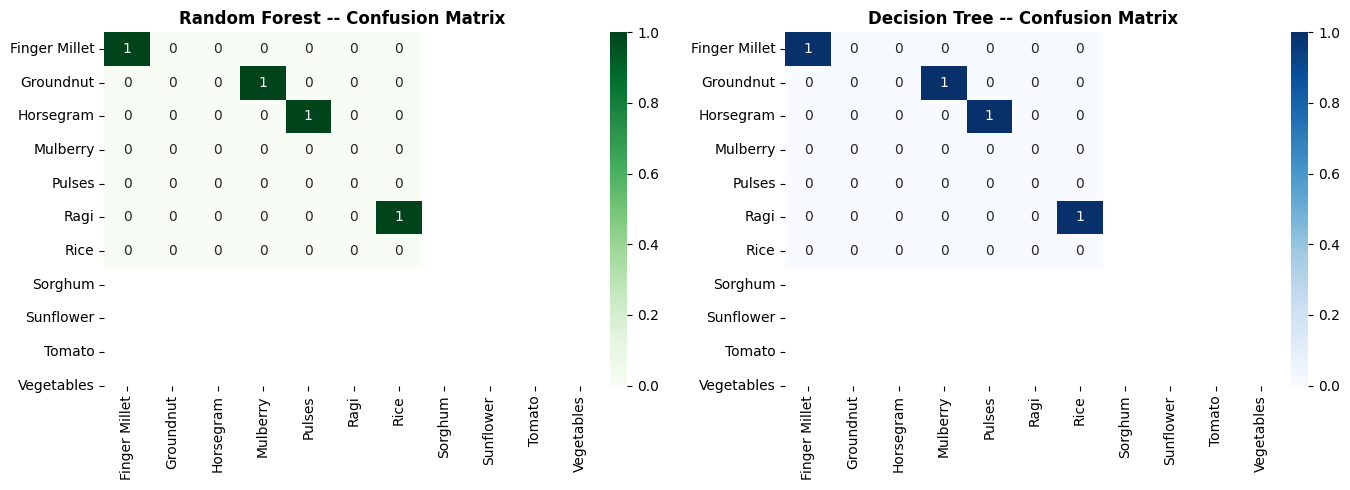

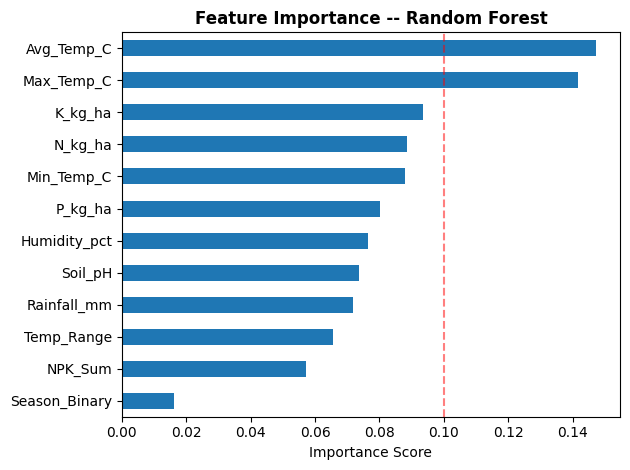

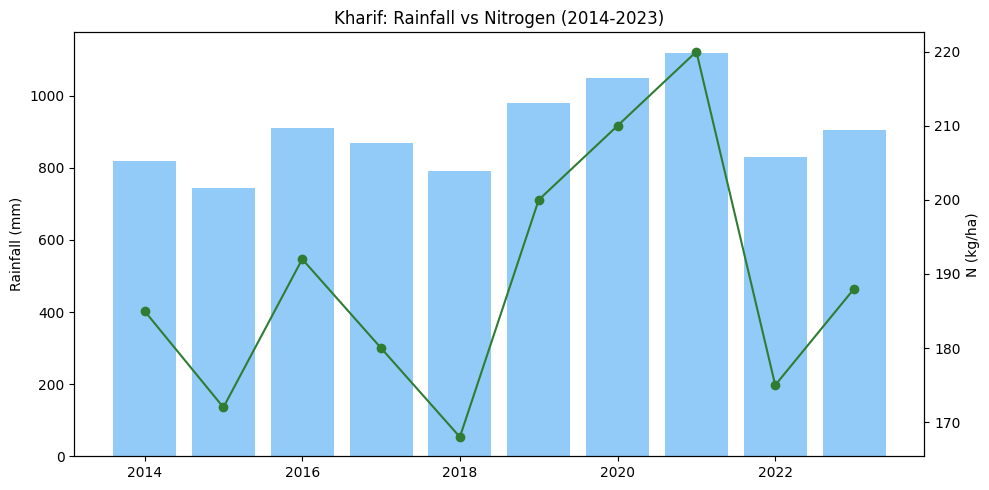

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import io

csv_data = """Year,Season,Rainfall_mm,Avg_Temp_C,Max_Temp_C,Min_Temp_C,Humidity_pct,Soil_pH,N_kg_ha,P_kg_ha,K_kg_ha,Recommended_Crop
2014,Kharif,820,26.2,34.1,18.5,62,6.2,185,18,198,Finger Millet
2014,Rabi,180,22.1,30.2,14.0,55,6.2,180,17,200,Groundnut
2015,Kharif,745,27.0,35.5,19.2,58,6.1,172,16,210,Groundnut
2015,Rabi,155,23.0,31.5,14.8,52,6.1,168,15,212,Sorghum
2016,Kharif,910,25.8,33.8,17.8,65,6.3,192,20,195,Ragi
2016,Rabi,210,21.5,29.8,13.5,58,6.3,188,19,197,Pulses
2017,Kharif,870,26.5,34.7,18.2,63,6.2,180,17,202,Tomato
2017,Rabi,195,22.5,30.8,14.2,56,6.2,176,16,204,Finger Millet
2018,Kharif,790,27.3,36.0,19.8,59,6.0,168,15,215,Groundnut
2018,Rabi,162,23.5,32.0,15.0,51,6.0,164,14,217,Sunflower
2019,Kharif,980,25.5,33.2,17.5,67,6.4,200,22,190,Ragi
2019,Rabi,228,21.2,29.5,13.2,60,6.4,196,21,192,Rice
2020,Kharif,1050,25.2,32.8,17.0,70,6.5,210,24,185,Mulberry
2020,Rabi,245,20.8,28.9,12.8,62,6.5,206,23,187,Vegetables
2021,Kharif,1120,24.9,32.5,16.8,72,6.6,220,26,178,Rice
2021,Rabi,258,20.5,28.5,12.5,65,6.6,216,25,180,Tomato
2022,Kharif,830,26.8,35.2,18.8,61,6.1,175,16,208,Groundnut
2022,Rabi,172,22.8,31.2,14.5,54,6.1,171,15,210,Horsegram
2023,Kharif,905,26.4,34.5,18.0,64,6.3,188,19,200,Finger Millet
2023,Rabi,198,22.0,30.5,13.8,57,6.3,184,18,202,Pulses"""

df = pd.read_csv(io.StringIO(csv_data))
print('Dataset shape:', df.shape)

df.fillna(method='ffill', inplace=True)
df['Season_Binary'] = df['Season'].map({'Kharif': 0, 'Rabi': 1})
df['Temp_Range'] = df['Max_Temp_C'] - df['Min_Temp_C']
df['NPK_Sum']    = df['N_kg_ha'] + df['P_kg_ha'] + df['K_kg_ha']

features = ['Rainfall_mm','Avg_Temp_C','Max_Temp_C','Min_Temp_C',
            'Humidity_pct','Soil_pH','N_kg_ha','P_kg_ha','K_kg_ha',
                        'Season_Binary','Temp_Range','NPK_Sum']
X = df[features]
y = df['Recommended_Crop']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
acc_dt = accuracy_score(y_test, y_pred_dt)

# Use KFold for cross-validation due to small number of samples in some classes
kf = KFold(n_splits=min(5, len(y_encoded)), shuffle=True, random_state=42)
cv_rf  = cross_val_score(rf_model, X_scaled, y_encoded, cv=kf).mean()

print(f'Random Forest Accuracy : {acc_rf*100:.1f}%')
print(f'Decision Tree Accuracy : {acc_dt*100:.1f}%')
print(f'RF Cross-Val Accuracy  : {cv_rf*100:.1f}%')

unique_labels_in_test = np.unique(np.concatenate((y_test, y_pred_rf)))
target_names_for_report = le.inverse_transform(unique_labels_in_test)
print(classification_report(y_test, y_pred_rf, labels=unique_labels_in_test, target_names=target_names_for_report))

# Single prediction
new_data   = pd.DataFrame([[950,25.8,33.5,17.5,66,6.3,195,20,193,0,16.0,408]],
                           columns=features)
pred_crop  = le.inverse_transform(rf_model.predict(scaler.transform(new_data)))
print(f'Recommended Crop: {pred_crop[0]}')

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d',
            cmap='Greens', xticklabels=le.classes_,
                        yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Random Forest -- Confusion Matrix', fontweight='bold')
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d',
            cmap='Blues', xticklabels=le.classes_,
                        yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Decision Tree -- Confusion Matrix', fontweight='bold')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150); plt.show()

# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=features)
importances.sort_values(ascending=True).plot(kind='barh')
plt.title('Feature Importance -- Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.axvline(x=0.10, color='red', linestyle='--', alpha=0.5)
plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150); plt.show()

# Rainfall vs Nitrogen
kharif = df[df['Season']=='Kharif'].sort_values('Year')
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.bar(kharif['Year'], kharif['Rainfall_mm'], color='#64B5F6', alpha=0.7)
ax1.set_ylabel('Rainfall (mm)')
ax2 = ax1.twinx()
ax2.plot(kharif['Year'], kharif['N_kg_ha'], 'o-', color='#2E7D32')
ax2.set_ylabel('N (kg/ha)')
plt.title('Kharif: Rainfall vs Nitrogen (2014-2023)')
plt.tight_layout(); plt.savefig('rainfall_vs_N.png', dpi=150); plt.show()